[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/3_cond%2Bstab/3_cond%2Bstab.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt

# Optional: a library for plotting with LaTeX-like 
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

In [2]:
import os
os.makedirs("results", exist_ok=True)

# Unit 3: Conditioning and stability

## Lecture 18: Conditioning and condition numbers

### Code demo 1: Condition number of the Vandermonde matrix

The Vandermonde matrix is often used in finding the coefficients of polynomial interpolation with monomial basis (equally-sapced points).

To fit a polynomial of degree-$n$, we have the linear system $Va=p$:
$$
\underbrace{\begin{bmatrix}
    1      & x_0    & x_0^2  & \cdots & x_0^n  \\[2pt]
    1      & x_1    & x_1^2  & \cdots & x_1^n  \\[2pt]
    1      & x_2    & x_2^2  & \cdots & x_2^n  \\[2pt]
    \vdots & \vdots & \vdots & \ddots & \vdots \\[2pt]
    1      & x_m    & x_m^2  & \cdots & x_m^n
\end{bmatrix}}_V.
\underbrace{\begin{bmatrix}
    a_0  \\[2pt]
    a_1  \\[2pt]
    \vdots  \\[2pt]
    a_n 
\end{bmatrix}}_a =
\underbrace{\begin{bmatrix}
    p(x_0)  \\[2pt]
    p(x_1)  \\[2pt]
    p(x_2)  \\[2pt]
    \vdots  \\[2pt]
    p(x_m)
\end{bmatrix}}_p
$$
where $p$ contain the data points.

Normally, we will solve the coefficients $a$ with $a = V^{-1} p$. However, it is never a good idea to do inverse in numerical linear algebra! And we will see that how the condition number of the Vandermonde matrix quickly increases as $n$ gets larger.

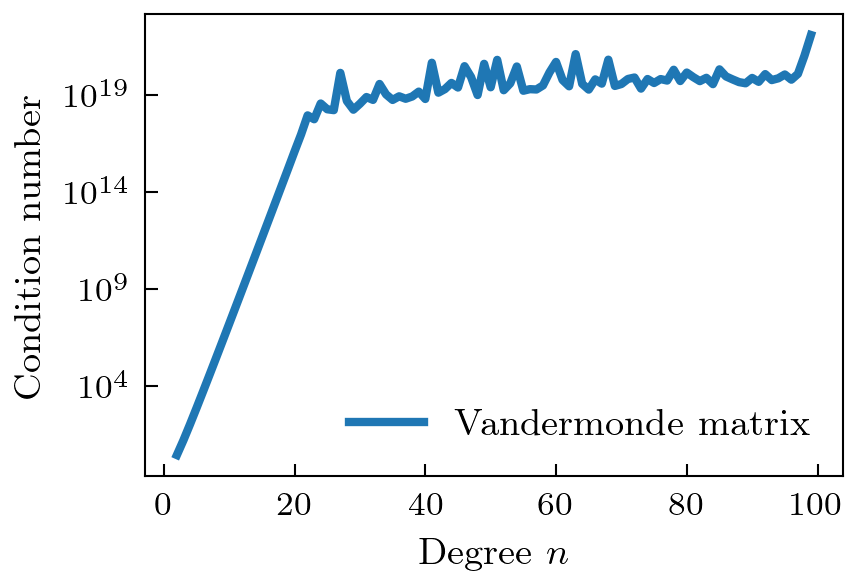

In [3]:
ns = np.arange(2, 100) # degree of the polynomial

# Loop through the values of n and create the Vandermonde matrix
# Calculate the condition number
kappas = []
for n in ns:
    x = np.linspace(0, 1, n) # n points in the interval [-1, 1]
    V = np.vander(x, increasing=True)
    kappa = np.linalg.cond(V)
    kappas.append(kappa)

# Plot the condition number as a function of n
fig, ax = plt.subplots(figsize=(3, 2), dpi=300)
ax.plot(ns, kappas, label='Vandermonde matrix', color='tab:blue', lw=2)

# Formatting
# ax.set_ylim(1e2, 1e10)
ax.set_xlabel('Degree $n$', fontsize=9)
ax.set_ylabel('Condition number', fontsize=9)
ax.set_yscale('log')
ax.legend(loc='lower right', fontsize=9)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/vander_cond.pdf', bbox_inches='tight', transparent=True)
plt.show()

### Code demo 2: Condition number of nonsymmetric matrix

Consider the two matrices
$$
A = \begin{bmatrix}
        1 & 1000 \\
        0 & 1
    \end{bmatrix} \quad\text{and}\quad
    B = \begin{bmatrix}
        1 & 1000 \\
        0.001 & 1
    \end{bmatrix}
$$
whose eigenvalues are $\{1,1\}$ and $\{0,2\}$, respectively.

In [4]:
A = np.array([[1, 1000], 
              [0, 1]])
B = np.array([[1, 1000], 
              [0.001, 1]])
# Calculate eigenvalues
eigs_A = np.linalg.eigvals(A)
eigs_B = np.linalg.eigvals(B)
print(f'Eigenvalues of A: {eigs_A}')
print(f'Eigenvalues of B: {eigs_B}')
# Calculate condition numbers
kappa_A = np.linalg.cond(A)
kappa_B = np.linalg.cond(B)
print(f'Condition number of A: {kappa_A:.2e}')
print(f'Condition number of B: {kappa_B:.2e}')

Eigenvalues of A: [1. 1.]
Eigenvalues of B: [ 2.00000000e+00 -2.08166817e-17]
Condition number of A: 1.00e+06
Condition number of B: 3.64e+22


## Lecture 21: Stability

### Code demo 1: Backward stability of Householder triangularization

In [5]:
# Set a random seed for reproducibility
np.random.seed(1)
# Set R to a 50x50 upper-triangular matrix with normal random entries
R = np.triu(np.random.randn(50, 50))
# Set Q to a random orthogonal matrix by orthogonalizing a random matrix
Q, _ = np.linalg.qr(np.random.randn(50, 50))
# Set A to the product of QR, up to rounding errors
A = Q @ R
# Compute QR factorization A \sim Q_2 R_2 by Householder triangularization
Q_2, R_2 = np.linalg.qr(A)

These four lines is to construct a matrix with a known QR factorization, $A=QR$, which can then be compared with the QR factorization $A=Q_2R_2$ computed by Householder triangularization.

Actually, because of rounding errors, the QR factors of the computed matrix $A$ are not exactly $Q$ and $R$. However, for the purposes of this demo, they are close enough.

Now we compute the difference between $Q$ and $Q_2$, and $R$ and $R_2$, individually. As it happens, they are very far from exact:

In [6]:
# How accurate is Q_2
accuracy_Q2 = np.linalg.norm(Q - Q_2) / np.linalg.norm(Q)
print(f'Accuracy of Q_2: {accuracy_Q2:.16f}')
# How accurate is R_2
accuracy_R2 = np.linalg.norm(R - R_2) / np.linalg.norm(R)
print(f'Accuracy of R_2: {accuracy_R2:.16f}')

Accuracy of Q_2: 0.0095841068800163
Accuracy of R_2: 0.0011153474012104


These errors are huge!

Our calculations have been done with sixteen digits of accuracy, yet the final results are accurate to only two or three digits. The individual rounding errors have been amplified by factors on the order ot $10^{13}$.

But now, an astonishing thing happens when we multiply these inaccurate matrices $Q_2$ and $R_2$:

In [7]:
# How accurate is Q_2 R_2
accuracy_Q2R2 = np.linalg.norm(A - Q_2 @ R_2) / np.linalg.norm(A)
print(f'Accuracy of Q_2 R_2: {accuracy_Q2R2:.16e}')

Accuracy of Q_2 R_2: 5.4599716767742469e-16


The product $Q_2R_2$ is accurate to a full fifteen digits! The errors in $Q_2$ and $R_2$ have to be "diabolically correlated". To one part in $10^{12}$, they cancel out in the product $Q_2R_2$.

To highlight how special this accuracy of $Q_2R_2$ is, let us construct another pair of matrices $Q_3$ and $R_3$ that are equally accurate approximations to $Q$ and $R$, and multiply them.

In [8]:
# Set Q_3 to a random perturbation of Q that is closer to Q than Q_2
Q_3 = Q + 1e-4 * np.random.randn(50, 50)
# Set R_3 to a random perturbation of $R$ that is closer to R than R_2
R_3 = R + 1e-4 * np.random.randn(50, 50)
# How accurate is Q_3 R_3
accuracy_Q3R3 = np.linalg.norm(A - Q_3 @ R_3) / np.linalg.norm(A)
print(f'Accuracy of Q_3 R_3: {accuracy_Q3R3:.16e}')

Accuracy of Q_3 R_3: 7.3232459376476404e-04


This time, the error in the product is huge.

$Q_2$ is no better than $Q_3$, and $R_2$ is no better than $R_3$, but $Q_2R_2$ is twelves order of magnitude better than $Q_3R_3$.

The errors in $Q_2$ and $R_2$ are forward errors. In general, a large forward error can be the result of an ill-conditioned problem or an unstable algorithm, and in this demo, it is the former. As a rule, the sequences of column spaces of a random triangular matrix are exceedingly ill-conditioned as a function of the entries of the matrix.

The error in $Q_2R_2$ is the backward error or residual. The smallness of this error suggests that Householder triangularization is backward stable.